<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/2_2_adding_hidden_layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Simple Model...
Training Hidden Layer Model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

=== Predictions Comparison ===
 Input |     Simple |     Hidden |     Actual
--------------------------------------------
   1.5 |       2.26 |      -0.88 |       2.20
   2.5 |       3.65 |      -1.62 |       3.50
   3.5 |       5.04 |      -2.36 |       5.00
   5.5 |       7.82 |      -3.84 |       7.90
   6.5 |       9.21 |      -4.58 |       9.20
   8.0 |      11.29 |      -5.69 |      10.50


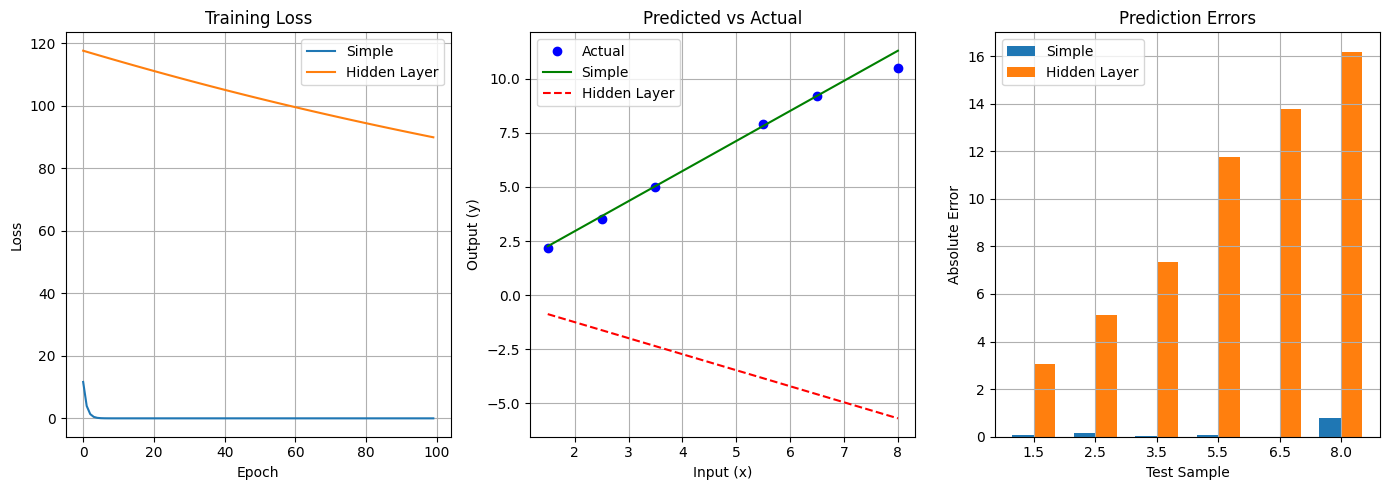

In [1]:
# Import required libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Dataset
# ----------------------------
x_train = np.array([1, 2, 3, 4, 5, 6, 7], dtype=float)
y_train = np.array([1.5, 3.1, 4.2, 6.0, 7.1, 8.5, 9.8], dtype=float)

x_test = np.array([1.5, 2.5, 3.5, 5.5, 6.5, 8.0], dtype=float)
y_test = np.array([2.2, 3.5, 5.0, 7.9, 9.2, 10.5], dtype=float)

# ----------------------------
# Step 2: Define Two Models
# ----------------------------

# 🔹 Model 1: Simple (no hidden layer)
model_simple = keras.Sequential([
    keras.layers.Dense(units=1, input_shape=[1])
])
model_simple.compile(optimizer='sgd', loss='mean_squared_error')

# 🔸 Model 2: With hidden layer
model_hidden = keras.Sequential([
    keras.layers.Dense(units=4, activation='relu', input_shape=[1]),
    keras.layers.Dense(units=1)
])
model_hidden.compile(optimizer='adam', loss='mean_squared_error')

# ----------------------------
# Step 3: Train Both Models
# ----------------------------
print("Training Simple Model...")
history_simple = model_simple.fit(x_train, y_train, epochs=100, verbose=0)

print("Training Hidden Layer Model...")
history_hidden = model_hidden.fit(x_train, y_train, epochs=100, verbose=0)

# ----------------------------
# Step 4: Predict Test Data
# ----------------------------
pred_simple = model_simple.predict(x_test)
pred_hidden = model_hidden.predict(x_test)

# ----------------------------
# Step 5: Compare Results
# ----------------------------
print("\n=== Predictions Comparison ===")
print(f"{'Input':>6} | {'Simple':>10} | {'Hidden':>10} | {'Actual':>10}")
print("-" * 44)
for i in range(len(x_test)):
    print(f"{x_test[i]:6.1f} | {pred_simple[i][0]:10.2f} | {pred_hidden[i][0]:10.2f} | {y_test[i]:10.2f}")

# ----------------------------
# Step 6: Plot Loss Comparison
# ----------------------------
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(history_simple.history['loss'], label='Simple')
plt.plot(history_hidden.history['loss'], label='Hidden Layer')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# ----------------------------
# Step 7: Plot Prediction Comparison
# ----------------------------
plt.subplot(1, 3, 2)
plt.plot(x_test, y_test, 'bo', label='Actual')
plt.plot(x_test, pred_simple, 'g-', label='Simple')
plt.plot(x_test, pred_hidden, 'r--', label='Hidden Layer')
plt.title('Predicted vs Actual')
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.legend()
plt.grid(True)

# ----------------------------
# Step 8: Plot Zoomed-In Error Comparison
# ----------------------------
plt.subplot(1, 3, 3)
errors_simple = abs(pred_simple.flatten() - y_test)
errors_hidden = abs(pred_hidden.flatten() - y_test)
bar_width = 0.35
indices = np.arange(len(x_test))

plt.bar(indices, errors_simple, width=bar_width, label='Simple')
plt.bar(indices + bar_width, errors_hidden, width=bar_width, label='Hidden Layer')
plt.title('Prediction Errors')
plt.xlabel('Test Sample')
plt.ylabel('Absolute Error')
plt.xticks(indices + bar_width / 2, [f"{x:.1f}" for x in x_test])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()